

1. Load the dataset
2. Explore the dataset
3. Handle missing values ( if any )
4. Check duplicates
5. Calculate mean, median, std
6. Detect Outliers( IQR, LL, UL )
7. Normalize numerical features
8. Standardize numerical features
9. Save the clean dataset

1. Remove unnecessary features
2. Which features are categorical and which are numerical ?
3. Update a value of dataset by selecting a row or column

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset

In [122]:
import seaborn as sns
df = sns.load_dataset('titanic')

In [123]:
df_backup = df.copy()

# Explore the dataset

In [124]:
df.head()
#df = pd.DataFrame( df ) - not required yet

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [125]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [127]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [128]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [129]:
col_corr = {  }
for col in df.columns:
  col_corr[col] = len(df[col])

print(col_corr)

{'survived': 891, 'pclass': 891, 'sex': 891, 'age': 891, 'sibsp': 891, 'parch': 891, 'fare': 891, 'embarked': 891, 'class': 891, 'who': 891, 'adult_male': 891, 'deck': 891, 'embark_town': 891, 'alive': 891, 'alone': 891}


In [130]:
max_samples = 0
for key in col_corr.keys():
  if( col_corr[key] > max_samples ) :
    max_samples = col_corr[key]
    #max_col = key

print(max_samples)

891


# Q1) Which features are categorical and which are numerical ?

Ans :

*   Categorical


1. sex
2. embarked
3. who
4. deck
5. embark_town
6. alive


*   Numerical


1. survived
2. pclass
3. age
4. sibsp
5. parch
6. fare
7. class
8. adult_male
9. alone







# Q2) Remove unnecessary features

1. since "sex" and "who" columns give information about the same data,
either of them can be removed.


In [131]:
df = df.drop("who", axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,NaN,Southampton,no,True


2. since "survived" and "alive" columns give information about the same data,
either of them can be removed;
removing "alive" is more preferrable since "survived" is already present in one hot encoding format


In [132]:
df = df.drop("alive", axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,NaN,Southampton,True


3. since we cannot calculate mean or other operations for string or categorical data ( columns "embark_town" and "deck" ) , we will replace the null values with a substitute string; say 'U'

In [133]:
#df["embark_town"].replace( np.nan, "U", inplace=True )
#df["deck"].replace( np.nan, "U", inplace=True )

df["embarked"] = df["embarked"].fillna( "U")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,NaN,Southampton,True


In [134]:
#df["deck"] =  df["deck"].fillna(  )
#df.head()

df = df.drop( "deck",axis=1 )
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,True


In [135]:
df = df.drop( "deck",axis=1 )
df.head()

KeyError: "['deck'] not found in axis"

In [136]:
df = df.drop( "embark_town",axis=1 )
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,True


In [137]:
'''
male_above18_avg = (df[ (df["sex"]=="male") & (df["age"]>=18) ])[ "age" ].mean()
#female_above18_avg = df[ df["sex"]=="Female" & df["age"]>=18 ][ "age" ].mean()
male_below18_avg = (df[ (df["sex"]=="male") & (df["age"]<18) ][ "age" ]).mean()
#female_above18_avg = df[ df["sex"]=="Female" & df["age"]<18 ][ "age" ].mean()
female_avg = (df[ df["sex"]=="Female"])[ "age" ].mean()
'''
male_avg = (df[ df["sex"]=="male" ])[ "age" ].mean()
female_avg = (df[ df["sex"]=="female" ])[ "age" ].mean()

In [138]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,0
class,0
adult_male,0


In [ ]:
'''
age_col = df["age"]
adult_male_col = df["adult_male"]
gender_col = df["sex"]

for i in range(len(age_col)) :
    if( age_col[i] == None ) :
        if( gender_col[i]=="female" ) :
            age_col[i] = female_avg

        else :
            if( gender_col[i]=="male" and adult_male_col[i]==False ) :
                age_col[i] =  male_below18_avg
            elif( gender_col[i]=="male" and adult_male_col[i]==True ) :
                age_col[i] = male_above18_avg
'''

In [139]:
#df["age"] = ((df[ df["sex"] == "male"  ])["age"]).fillna( male_avg )
#df["age"] = ((df[ df["sex"] == "female"  ])["age"]).fillna( female_avg )

df["age"] = df["age"].fillna( df["age"].mean() )

In [140]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
adult_male,0


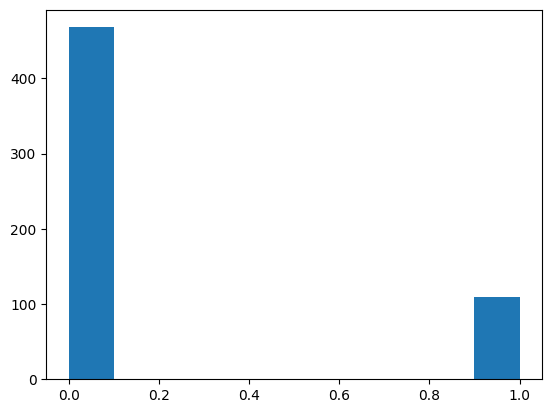

In [147]:
plt.hist( (df[ df["sex"]=='male' ])["survived"] )
plt.show()

In [ ]:
#plt.plot( np.arange( max_samples ), df["embark_town"] )